# Task 3 Table Retrieval

# 1. Feature Extraction & Content-Based Image Retrieval (CBIR)

Instead of matching raw pixels, you extract high-level features from the query image and compare them against your training data.

 - Global Image Embeddings: Pass the image through a pre-trained Deep Neural Network (like ResNet, ViT, or CLIP) to get a dense vector embedding representing the whole scene.

 - Metric Learning (Triplet Loss / Contrastive Learning): Train a network so that similar pool table configurations end up close together in the vector space, while drastically different setups are pushed far apart.

 - Vector Similarity Search: Use libraries like FAISS (Facebook AI Similarity Search) or Chroma to instantly retrieve the top-k nearest neighbors (most similar tables) using cosine similarity or Euclidean distance.

# Vector Similarity Search

In [6]:
import torch
from torchvision.transforms import v2 as transforms
from torch.nn import functional as F
import torchvision
import matplotlib.pyplot as plt
import os, random, re
import pandas as pd
import numpy as np
from PIL import Image

In [7]:
class PoolDataset:
    def __init__(self, root, partition_file, partition, transform=None):
        self.root = root
        partition_file = pd.read_csv(partition_file)

        idx = np.where(np.asarray(partition_file['partition'].values) == partition)[0]
        self.files = np.asarray(partition_file['image_name'].values)[idx]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        image = Image.open(os.path.join(self.root, self.files[i]))
        if self.transform:
            image = self.transform(image)
        return image

In [ ]:
val_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToDtype(torch.float32, True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

aug_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((256, 256)),
    # TODO - define here some data augmentations for training the image reconstruction model 
    transforms.RandomAffine(
        degrees=15,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1),
        shear=5
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    # (these are not strictly needed but can help avoid overfitting)
    transforms.CenterCrop((224, 224)),
    transforms.ToDtype(torch.float32, True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = PoolDataset('images', 'partition.csv', 'train', aug_transform)
val_dataset = PoolDataset('images', 'partition.csv', 'valid', val_transform)

batch_size = 8
num_workers = 2

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True, num_workers=num_workers)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size, num_workers=num_workers)

In [14]:
import torchvision.models as models

class FeatureExtractor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # load resnet backbone (or any other backbone of your choosing)
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # get the feature extractor of the pretrained model (by removing the classification head from the model)
        self.encoder = torch.nn.Sequential(*list(backbone.children())[:-1])
        # freeze the model
        for param in self.encoder.parameters():
            param.requires_grad = False

    def forward(self, x):
        x = self.encoder(x)
        return x
model = FeatureExtractor()

# TODO: finetune with all datasets from slides

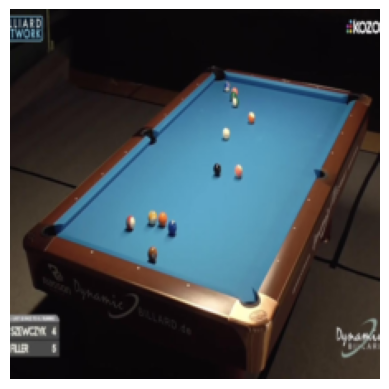

In [15]:
query_image = val_dataset[0]
query_image_show = query_image.permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
plt.imshow(query_image_show)
_ = plt.axis("off")

In [25]:
# apply model to obtain the representation of the query image
print(query_image.shape)
query_features = model.forward(query_image.unsqueeze(0))
print(query_features.shape)

similarities = np.zeros((len(train_dataset),))
for i in range(len(train_dataset)):
  train_features = model(train_dataset[i].unsqueeze(0)) 
  similarities[i] = F.cosine_similarity(query_features, train_features, dim=1)

# get indexes of top 5 most similar images
top5_idx = np.argsort(similarities)[::-1][:5]

torch.Size([3, 224, 224])
torch.Size([1, 512, 1, 1])


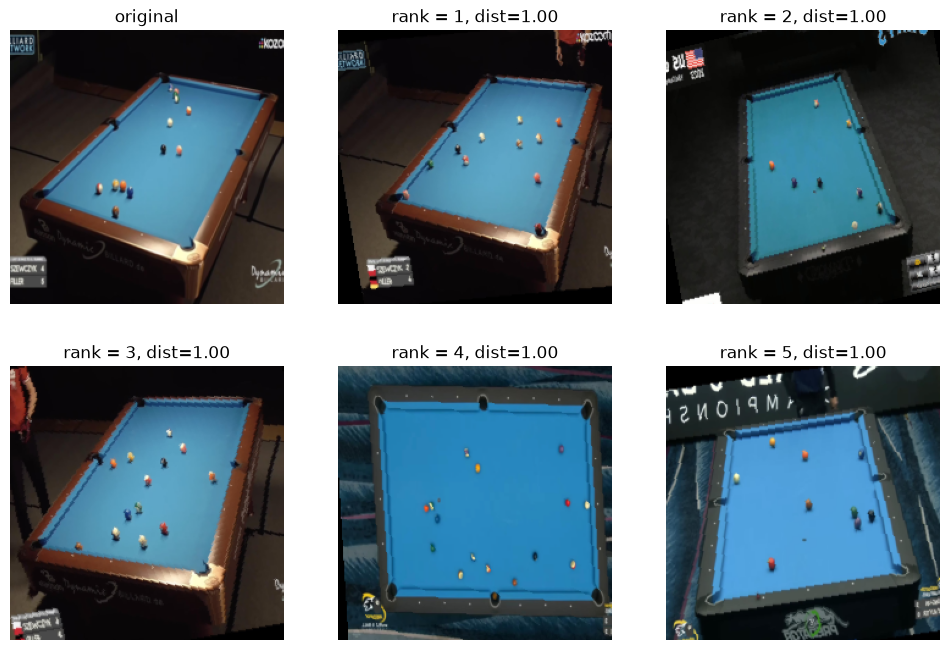

In [26]:
f, axarr = plt.subplots(2, 3, figsize=(12, 8))
axarr[0][0].imshow(query_image_show)
axarr[0][0].set_title("original")
axarr[0][0].axis("off")
for j in range(1, 6):
  img_show = train_dataset[top5_idx[j-1]].permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
  axarr[j // 3][j % 3].imshow(img_show)
  axarr[j // 3][j % 3].set_title(f"rank = {j}, dist={similarities[top5_idx[j-1]]:.2f}")
  axarr[j // 3][j % 3].axis("off")

# Contrastive Learning

In [2]:
import torch
from torchvision.transforms import v2 as transforms
from torch.nn import functional as F
import torchvision
import matplotlib.pyplot as plt
import os, random, re
import pandas as pd
import numpy as np
from PIL import Image

In [35]:
import os
import re
import random
import numpy as np
import pandas as pd
from PIL import Image

class PoolDataset:
    def __init__(self, root, partition_file, partition, transform=None):
        self.root = root
        partition_file = pd.read_csv(partition_file)

        idx = np.where(np.asarray(partition_file['partition'].values) == partition)[0]
        self.files = np.asarray(partition_file['image_name'].values)[idx]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        image = Image.open(os.path.join(self.root, self.files[i]))
        if self.transform:
            image = self.transform(image)
        return image

class TripletPoolDataset:
    def __init__(self, root, partition_file, partition, transform=None, val_transform=None):
        self.root = root
        partition_df = pd.read_csv(partition_file)

        idx = np.where(np.asarray(partition_df['partition'].values) == partition)[0]
        self.files = np.asarray(partition_df['image_name'].values)[idx]
        self.transform = transform
        self.val_transform = val_transform
        self.partition = partition

        # 1. Extract numeric identifiers from the filenames to act as labels
        self.labels = np.array([self._get_label(f) for f in self.files])

        # 2. Pre-compute positive index maps to speed up __getitem__
        self.label_to_indices = {
            label: np.where(self.labels == label)[0] 
            for label in np.unique(self.labels)
        }

    def _get_label(self, filename):
        # Extracts the leading digits from the filename (e.g., '3t_png...' -> '3')
        match = re.match(r'^(\d+)', filename)
        return match.group(1) if match else filename

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        anchor_img_name = self.files[i]
        anchor_label = self.labels[i]

        image_query_pil = Image.open(os.path.join(self.root, anchor_img_name))

        # --- POSITIVE PAIR LOGIC ---
        # Find all files with the same numeric label, excluding the current anchor index
        pos_candidates = self.label_to_indices[anchor_label]
        pos_candidates = pos_candidates[pos_candidates != i]

        if len(pos_candidates) > 0:
            # Pick a random different image that shares the same number (e.g., '3f' for '3t')
            pos_idx = random.choice(pos_candidates)
            image_pos_pil = Image.open(os.path.join(self.root, self.files[pos_idx]))
        else:
            # Fallback: If no other image shares the number, use the anchor itself
            image_pos_pil = image_query_pil

        # --- NEGATIVE PAIR LOGIC ---
        if self.partition == "train":
            # Randomly guess until we hit an image with a different number
            neg_idx = random.randint(0, len(self.files) - 1)
            while self.labels[neg_idx] == anchor_label:
                neg_idx = random.randint(0, len(self.files) - 1)
        else:
            # Deterministic negative for validation: step forward until we hit a different number
            neg_idx = (i + 1) % len(self.files)
            while self.labels[neg_idx] == anchor_label:
                neg_idx = (neg_idx + 1) % len(self.files)

        image_neg_pil = Image.open(os.path.join(self.root, self.files[neg_idx]))

        # --- APPLY TRANSFORMS ---
        # Query and negative usually get the standard validation transforms
        image_query = self.val_transform(image_query_pil) if self.val_transform else image_query_pil
        image_neg = self.val_transform(image_neg_pil) if self.val_transform else image_neg_pil
        
        # Positive gets the heavier training augmentations
        image_pos = self.transform(image_pos_pil) if self.transform else image_pos_pil

        return image_query, image_pos, image_neg

In [37]:
val_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToDtype(torch.float32, True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

aug_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((256, 256)),
    # TODO - define here some data augmentations for training the image reconstruction model 
    transforms.RandomAffine(
        degrees=15,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1),
        shear=5
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    # (these are not strictly needed but can help avoid overfitting)
    transforms.CenterCrop((224, 224)),
    transforms.ToDtype(torch.float32, True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = TripletPoolDataset('images', 'partition.csv', 'train', aug_transform, val_transform)
val_dataset = TripletPoolDataset('images', 'partition.csv', 'valid',transform=val_transform, val_transform=val_transform)

train_dataset_infer = PoolDataset('images', 'partition.csv', 'train', aug_transform)
val_dataset_infer = PoolDataset('images', 'partition.csv', 'valid', val_transform)

batch_size = 8
num_workers = 2

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True, num_workers=num_workers)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size, num_workers=num_workers)

In [26]:
import torchvision.models as models
class FeatureExtractor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # load resnet backbone (or any other backbone of your choosing)
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # get the feature extractor of the pretrained model (by removing the classification head from the model)
        self.encoder = torch.nn.Sequential(*list(backbone.children())[:-1])
        # this time we want to train the encoder, so we do not freeze it

    def forward(self, x):
        x = self.encoder(x)
        return x

In [27]:
device = 'cpu'
print('using device:', device)

# create model
model = FeatureExtractor()
model = model.to(device)

using device: cpu


In [28]:
# Define optimizer
optimizer = torch.optim.AdamW(model.parameters())
epochs = 20

# Define loss
loss_fn = torch.nn.MSELoss(reduction="none")

In [29]:
def one_epoch(model, optimizer, dataloader, is_training):
  model.train() if is_training else model.eval()
  avg_loss = 0
  for i, (image_query, image_pos, image_neg) in enumerate(dataloader):
    image_query = image_query.to(device)
    image_pos = image_pos.to(device)
    image_neg = image_neg.to(device)
    # extract representations of the query, positive and negative samples using the feature extractor
    rep_query = model(image_query)
    rep_pos   = model(image_pos)
    rep_neg   = model(image_neg)

    # implement here the loss term to minimize the distance between the query and positive sample
    loss = torch.mean((rep_query - rep_pos) ** 2)
    # loss term used to maximize the distance between the query and its augmented version
    m = 1.
    loss += torch.mean(torch.maximum(m - loss_fn(rep_query, rep_neg), torch.zeros((len(image_query))).to(device)))
    
    if is_training:
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    avg_loss += loss.item() / len(dataloader)
  return avg_loss

In [30]:
train_history = {'loss': [], 'metric': []}
val_history = {'loss': [], 'metric': []}
for epoch in range(epochs):
  # compute train
  avg_loss = one_epoch(model, optimizer, train_dataloader, True)
  train_history['loss'].append(avg_loss)
  print(f'Epoch {epoch+1:2d}/{epochs} - Train loss: {avg_loss}')
  # compute validation statistics
  avg_loss = one_epoch(model, optimizer, val_dataloader, False)
  val_history['loss'].append(avg_loss)
  print(f'Epoch {epoch+1:2d}/{epochs} - Val   loss: {avg_loss}')

Epoch  1/20 - Train loss: 0.906949623272969
Epoch  1/20 - Val   loss: 0.492831289768219
Epoch  2/20 - Train loss: 0.7600509409721082
Epoch  2/20 - Val   loss: 0.6451907555262247
Epoch  3/20 - Train loss: 0.7408017275425104
Epoch  3/20 - Val   loss: 0.632791539033254
Epoch  4/20 - Train loss: 0.7540003657341002
Epoch  4/20 - Val   loss: 0.5336445470650991
Epoch  5/20 - Train loss: 0.7405720078028164
Epoch  5/20 - Val   loss: 0.662207047144572
Epoch  6/20 - Train loss: 0.7033450867121036
Epoch  6/20 - Val   loss: 0.516661008199056
Epoch  7/20 - Train loss: 0.7208265845592204
Epoch  7/20 - Val   loss: 0.4862615019083023
Epoch  8/20 - Train loss: 0.8066282868385316
Epoch  8/20 - Val   loss: 0.5422601501146952
Epoch  9/20 - Train loss: 0.7172267333819315
Epoch  9/20 - Val   loss: 0.508936603864034
Epoch 10/20 - Train loss: 0.7546047041049369
Epoch 10/20 - Val   loss: 0.5313795705636343
Epoch 11/20 - Train loss: 0.6410570179040616
Epoch 11/20 - Val   loss: 0.52277938524882
Epoch 12/20 - Trai

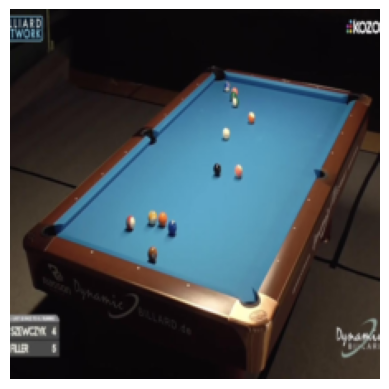

In [33]:
query_image = val_dataset[0][0]
query_image_show = query_image.permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
plt.imshow(query_image_show)
_ = plt.axis("off")

In [41]:
query_features = model(query_image.unsqueeze(0))

similarities = np.zeros((len(train_dataset_infer),))
for i in range(len(train_dataset_infer)):
  # apply model to obtain the representation of the retrieval candidate
  train_features = model(train_dataset_infer[i].unsqueeze(0)) 
  # compute mean squared error distance between query and candidate representations
  similarities[i] = F.cosine_similarity(query_features.detach(), train_features.detach(), dim=1)

# get indexes of top 5 most similar images
top5_idx = np.argsort(similarities)[::-1][:5]

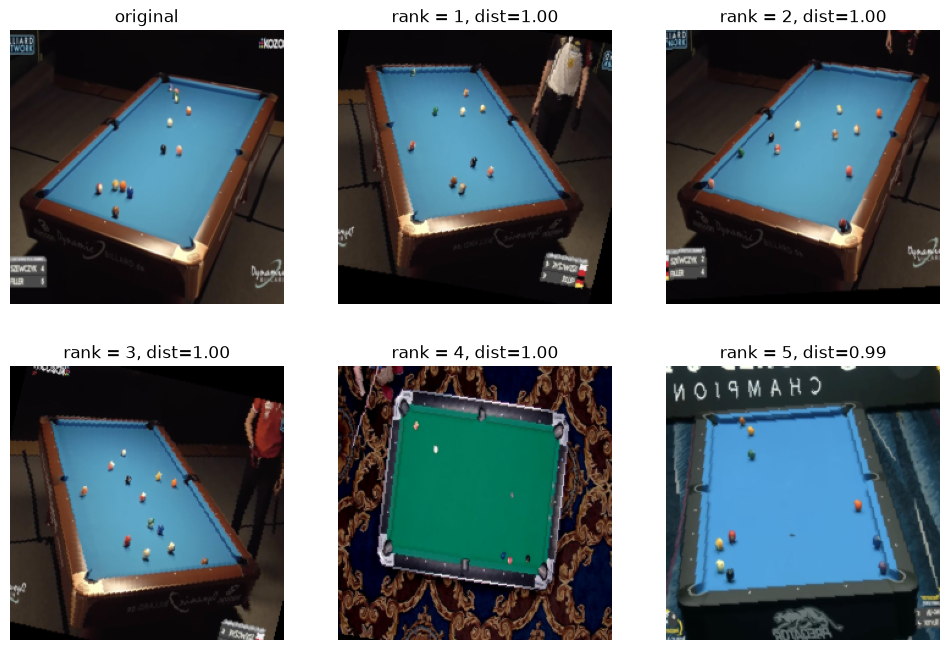

In [43]:
f, axarr = plt.subplots(2, 3, figsize=(12, 8))
axarr[0][0].imshow(query_image_show)
axarr[0][0].set_title("original")
axarr[0][0].axis("off")
for j in range(1, 6):
  img_show = train_dataset_infer[top5_idx[j-1]].permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
  axarr[j // 3][j % 3].imshow(img_show)
  axarr[j // 3][j % 3].set_title(f"rank = {j}, dist={similarities[top5_idx[j-1]]:.2f}")
  axarr[j // 3][j % 3].axis("off")



# 2. Object Detection & Spatial Graph Matching

Since a pool table's state is defined entirely by its boundaries and the coordinates of the balls, explicit geometric techniques work incredibly well here.

- Ball and Pocket Detection: Use an object detection model (like YOLOv8 or Faster R-CNN) to detect the precise bounding boxes of the balls, cue ball, and pockets (as seen outlined in your image).

- Homography Estimation (2D Projection): Detect the corners of the pool table to compute a homography matrix. Transform the skewed 3D camera perspective into a bird's-eye view (2D top-down grid).

- Graph Neural Networks (GNNs): Represent the table as a graph where nodes are balls (with color/type attributes) and edges represent the relative distance and angles between them. Table retrieval then becomes a Graph Matching problem.

In [1]:
%pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.4 MB/s eta 0:00:00


In [ ]:
import torch
from torchvision.transforms import v2 as transforms
from torch.nn import functional as F
import torchvision
import matplotlib.pyplot as plt
import os, random, re
import pandas as pd
import numpy as np
from PIL import Image

In [3]:
from google.colab import drive
import os
import zipfile

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import zipfile
from pathlib import Path

zip_file_path = "/content/drive/MyDrive/data/yolo_dataset.zip"

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print(f"Successfully extracted all files")

except FileNotFoundError:
    print(f"Error: The file '{zip_file_path}' was not found.")
except zipfile.BadZipFile:
    print("Error: The file is corrupted or not a valid zip archive.")

Successfully extracted all files


In [5]:
from ultralytics import YOLO

# 1. Initialize a new YOLOv8 nano model (or use 'yolov8s.pt' / 'yolov8m.pt' for larger models)
device = 'cuda'
model = YOLO("yolov8n.pt")

# 2. Train the model
results = model.train(
    data="./yolo_dataset/data.yaml",  # Path to the generated configuration file
    epochs=50,                        # Adjust based on how long you want to train
    imgsz=640,                        # Standard YOLO resolution
    device=device                          # Set to 0 if you have a GPU available, or "cpu"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64

In [9]:
import shutil
import os

# shutil.copy('/content/runs/detect/train/weights/best.pt', '/content/drive/MyDrive/data/pool_yolo_best.pt')
os.system("zip -r yolo_training_run.zip runs/detect/train")
shutil.copy('/content/yolo_training_run.zip', '/content/drive/MyDrive/data/yolo_training_run.zip')

'/content/drive/MyDrive/data/yolo_training_run.zip'


image 1/1 /home/ricardo/dev/CV_PROJECT_1/images/0_png.rf.e35063c144cfd241454863d624cf01d3.jpg: 384x640 1 Dot, 3 Solids, 2 Stripeds, 40.6ms
Speed: 1.9ms preprocess, 40.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
--- Detections ---
Detected [Striped] with 65.43% confidence at [803, 473, 819, 486]
Detected [Solid] with 48.64% confidence at [755, 463, 774, 481]
Detected [Solid] with 45.85% confidence at [754, 455, 772, 476]
Detected [Striped] with 43.33% confidence at [1060, 520, 1078, 539]


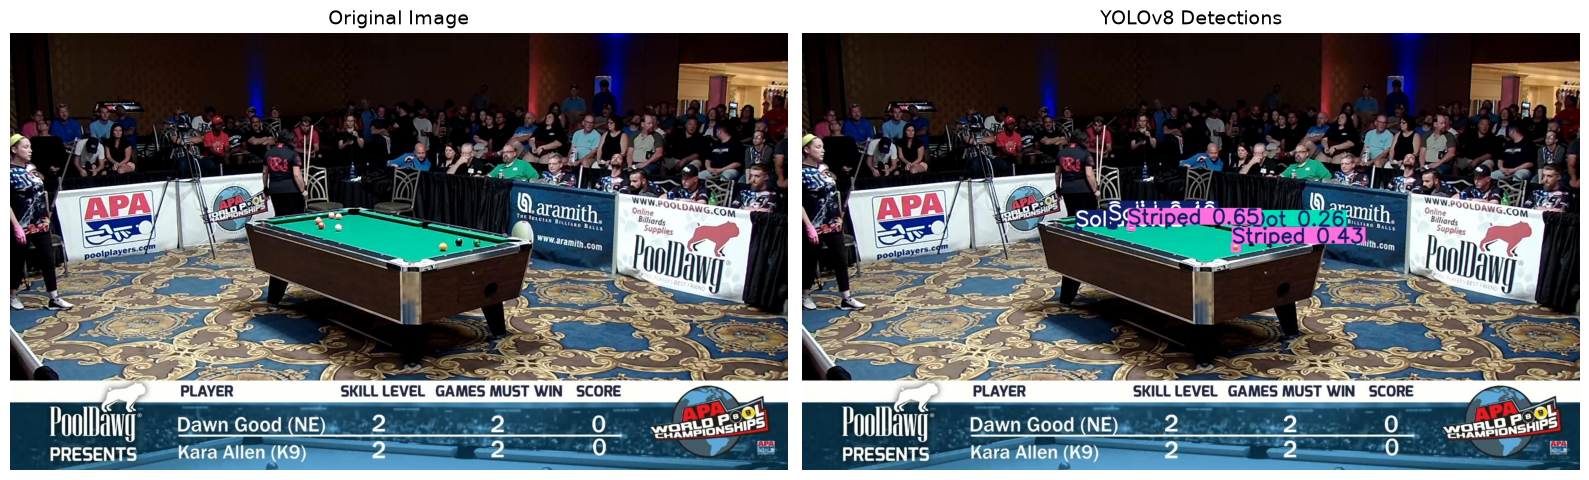

In [5]:
import cv2
from ultralytics import YOLO

# 1. Load your custom trained model
# Replace 'best.pt' with the actual path to your file if it's in another folder
model = YOLO("pool_yolo_best.pt")

# 2. Run inference on a local pool table image
# (Make sure this image path exists on your PC)
image_path = "images/0_png.rf.e35063c144cfd241454863d624cf01d3.jpg"
results = model(image_path, device='cpu')

print("--- Detections ---")
for result in results:
    boxes = result.boxes
    for box in boxes:
        # Get class ID and text name
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])
        
        # Coordinates: [x_min, y_min, x_max, y_max]
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        
        if confidence > 0.4:
            # Fixed formatting bug here:
            print(f"Detected [{class_name}] with {confidence:.2%} confidence at [{x1}, {y1}, {x2}, {y2}]")

# 3. Prepare the images for Matplotlib display
# Load original image and convert from BGR to RGB
orig_img = cv2.imread(image_path)
orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

# Get the annotated image from YOLO and convert from BGR to RGB
annotated_img = results[0].plot()
annotated_img_rgb = annotated_img[:, :, ::-1]

# 4. Plot Side-by-Side using Matplotlib
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left Plot: Original
axes[0].imshow(orig_img_rgb)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis("off")

# Right Plot: YOLO Detections
axes[1].imshow(annotated_img_rgb)
axes[1].set_title("YOLOv8 Detections", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Homography

Too  much work do this way again for the green velt pool table... but should be possible.